In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Pauli
from qiskit.circuit.library import QAOAAnsatz

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [24]:
import numpy as np

In [9]:
QiskitRuntimeService.save_account(channel='ibm_cloud', token="REMOVED")

Se implementa el algoritmo quantum approximate optimization algorithm sobre el hamiltoniano de coste H1 = Z0 Z1

no es necesario implementar el circuito puerta a puerta porque ya se incluye en qiskit.circuit.library

In [10]:
H1 = Pauli('ZZ')
circuit = QAOAAnsatz(cost_operator=H1, reps=1)
# reps es el numero de capas
circuit.measure_all()


circuit.draw()

┌──────────────────┐ ░ ┌─┐   
   q_0: ┤0                 ├─░─┤M├───
        │  QAOA(γ[0],β[0]) │ ░ └╥┘┌─┐
   q_1: ┤1                 ├─░──╫─┤M├
        └──────────────────┘ ░  ║ └╥┘
meas: 2/════════════════════════╩══╩═
                                0  1

In [11]:
# podemos ver las distintas partes del algoritmo (parte de H0 y H1)
circuit.decompose().draw()

┌───┐┌────────────────────┐┌───────────────────────────┐ ░ ┌─┐   
   q_0: ┤ H ├┤0                   ├┤0                          ├─░─┤M├───
        ├───┤│  exp(-it ZZ)(γ[0]) ││  exp(-it (XI + IX))(β[0]) │ ░ └╥┘┌─┐
   q_1: ┤ H ├┤1                   ├┤1                          ├─░──╫─┤M├
        └───┘└────────────────────┘└───────────────────────────┘ ░  ║ └╥┘
meas: 2/════════════════════════════════════════════════════════════╩══╩═
                                                                    0  1

In [12]:
# se puede descomponer en mayor detalle
# U(pi/2,0,pi) = H (puerta Hadamard) que es lo esperado en este circuito
circuit.decompose().decompose().draw()

┌────────────┐             ┌────────────┐ ░ ┌─┐   
   q_0: ┤ U(π/2,0,π) ├─■───────────┤ Rx(2*β[0]) ├─░─┤M├───
        ├────────────┤ │ZZ(2*γ[0]) ├────────────┤ ░ └╥┘┌─┐
   q_1: ┤ U(π/2,0,π) ├─■───────────┤ Rx(2*β[0]) ├─░──╫─┤M├
        └────────────┘             └────────────┘ ░  ║ └╥┘
meas: 2/═════════════════════════════════════════════╩══╩═
                                                     0  1

In [13]:
circuit.decompose().decompose().decompose().draw()

┌────────────┐                        ┌─────────────┐ ░ ┌─┐   
   q_0: ┤ U(π/2,0,π) ├──■──────────────────■──┤ R(2*β[0],0) ├─░─┤M├───
        ├────────────┤┌─┴─┐┌────────────┐┌─┴─┐├─────────────┤ ░ └╥┘┌─┐
   q_1: ┤ U(π/2,0,π) ├┤ X ├┤ Rz(2*γ[0]) ├┤ X ├┤ R(2*β[0],0) ├─░──╫─┤M├
        └────────────┘└───┘└────────────┘└───┘└─────────────┘ ░  ║ └╥┘
meas: 2/═════════════════════════════════════════════════════════╩══╩═
                                                                 0  1

In [14]:
# si yo quiero añadir mas capas del algoritmo: p > 1
p = 3
circuit = QAOAAnsatz(cost_operator=H1, reps=3)
circuit.decompose().draw()

┌───┐┌────────────────────┐┌───────────────────────────┐»
q_0: ┤ H ├┤0                   ├┤0                          ├»
     ├───┤│  exp(-it ZZ)(γ[0]) ││  exp(-it (XI + IX))(β[0]) │»
q_1: ┤ H ├┤1                   ├┤1                          ├»
     └───┘└────────────────────┘└───────────────────────────┘»
«     ┌────────────────────┐┌───────────────────────────┐┌────────────────────┐»
«q_0: ┤0                   ├┤0                          ├┤0                   ├»
«     │  exp(-it ZZ)(γ[1]) ││  exp(-it (XI + IX))(β[1]) ││  exp(-it ZZ)(γ[2]) │»
«q_1: ┤1                   ├┤1                          ├┤1                   ├»
«     └────────────────────┘└───────────────────────────┘└────────────────────┘»
«     ┌───────────────────────────┐
«q_0: ┤0                          ├
«     │  exp(-it (XI + IX))(β[2]) │
«q_1: ┤1                          ├
«     └───────────────────────────┘

qiskit_runtime_service.__init__:WARNING:2026-04-04 16:26:36,025: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-04 16:26:36,801: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-04 16:26:39,744: Using instance: open-instance, plan: open


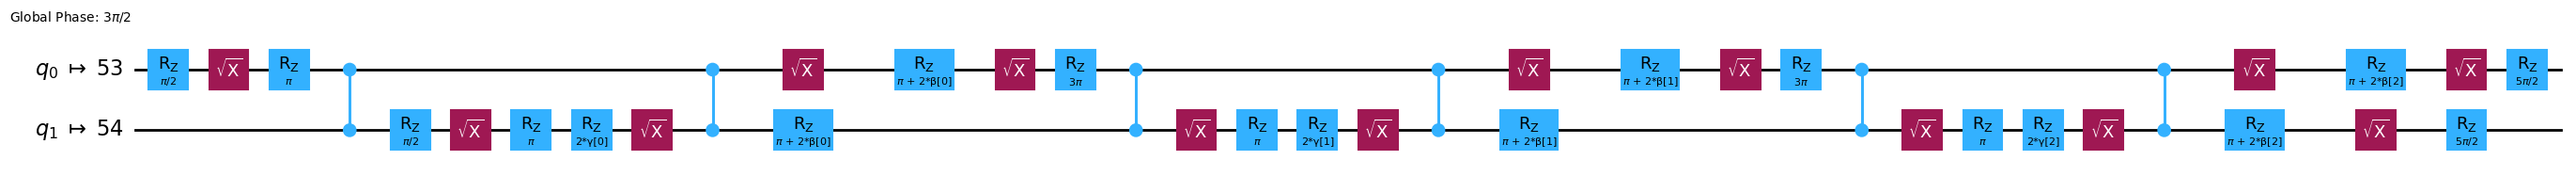

In [ ]:
# necesitamos ahora pasar los argumentos \beta y \gamma al circuito para que se ejecute el algoritmo de optimizacion
# antes de eso necesitamos que el circuito pueda correr en un QPU.
# Hemos dibujado un circuito teorico pero no todos los circuitos que se dibujan pueden ejecutarse directamente en un
# ordenador cuantico real (QPU) -> hay un proceso de transpilacion/optimizacion del circuito: conjunto de 
# transformaciones que conierten ese circuito en uno que si puede ejecutarse en hardware real

# LIMITACIONES ORDENADORES CUANTICOS REALES: 
# 1) solo admiten puertas cuanticas especificas (no admiten cualquier operacion)
# 2) no todos los qubits estan conectados entre si
# 3) hay errores de ruido que conviene minimizar (dispositivos NISQ)

# QUE HACE LA TRANSPILACION:
# 1) reescribe puertas: cambia las puertas abstractas por combinaciones de puertas reales del dispositivo
# 2) mapea qubits: asigna los qubits logicos del circuito a qubits fisicos del chip
# 3) inserta operaciones extra: añade swaps si dos qubirs no estan conectados directamente
# 4) optimiza: reduce el numero de puertas, minimiza errores y profundidad del circuito

service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False
)

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
candidate_circuit = pm.run(circuit)
#aqui ya tengo un circuito compatible con el QPU que estoy usando

candidate_circuit.draw('mpl',fold=False, idle_wires=False)

In [ ]:
# introducimos los parametros iniciales de forma arbitraria
initial_gamma = np.pi
initial_beta = np.pi / 2
init_params = [initial_beta, initial_beta, initial_gamma, initial_gamma]